In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from IPython.display import Image, display

SEED = 42
SIZES = ["m", "l", "xl"]

CNN_RUNS_ROOT = Path("../runs").expanduser()
FNO_RUNS_ROOT = Path("../runs").expanduser()


In [6]:
def find_latest_run_dir(runs_root: Path, prefix: str) -> Path | None:
    candidates = [p for p in runs_root.iterdir() if p.is_dir() and p.name.startswith(prefix)]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def make_curves(run_dir: Path):
    hist_path = run_dir / "history.csv"
    if not hist_path.exists():
        print("missing history.csv:", hist_path)
        return

    df = pd.read_csv(hist_path)

    epoch_col = "epoch" if "epoch" in df.columns else None
    if epoch_col is None:
        df["epoch"] = range(1, len(df) + 1)
        epoch_col = "epoch"

    train_col = pick_col(df, ["train_mse", "train_loss", "train"])
    val_col   = pick_col(df, ["val_mse", "val_loss", "val"])
    lr_col    = pick_col(df, ["lr", "learning_rate"])

    # loss curve (log) if we have train+val
    if train_col and val_col:
        plt.figure()
        plt.plot(df[epoch_col], df[train_col], label=f"train ({train_col})")
        plt.plot(df[epoch_col], df[val_col], label=f"val ({val_col})")
        plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("loss (log scale)")
        plt.title(run_dir.name)
        plt.legend()
        plt.tight_layout()
        plt.savefig(run_dir / "loss_curve_log.png", dpi=200)
        plt.close()
    else:
        print("no train/val loss columns found in", run_dir.name, "cols:", list(df.columns))

    # lr curve (log) if we have lr
    if lr_col:
        plt.figure()
        plt.plot(df[epoch_col], df[lr_col])
        plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("learning rate (log scale)")
        plt.title(run_dir.name)
        plt.tight_layout()
        plt.savefig(run_dir / "lr_curve.png", dpi=200)
        plt.close()
    else:
        print("no lr column found in", run_dir.name, "cols:", list(df.columns))


In [7]:
def get_latest_run_dirs_for_model(runs_root: Path, model_prefix: str, seed: int, sizes: list[str]):
    run_dirs = {}
    for s in sizes:
        preferred_prefix = f"{model_prefix}_{s}_seed{seed}"
        fallback_prefix  = f"{model_prefix}_{s}"

        d = find_latest_run_dir(runs_root, preferred_prefix) or find_latest_run_dir(runs_root, fallback_prefix)
        run_dirs[s] = d
    return run_dirs

cnn_run_dirs = get_latest_run_dirs_for_model(CNN_RUNS_ROOT, "cnn", SEED, SIZES)
fno_run_dirs = get_latest_run_dirs_for_model(FNO_RUNS_ROOT, "fno", SEED, SIZES)

cnn_run_dirs, fno_run_dirs


({'m': PosixPath('../runs/cnn_m_seed42_20260122_163308_seed42'),
  'l': PosixPath('../runs/cnn_l_seed42_20260122_233252_seed42'),
  'xl': PosixPath('../runs/cnn_xl_seed42_20260123_112702_seed42')},
 {'m': PosixPath('../runs/fno_m_seed42'),
  'l': PosixPath('../runs/fno_l_seed42'),
  'xl': PosixPath('../runs/fno_xl_seed42')})


=== CNN ===

 cnn_m_seed42_20260122_163308_seed42


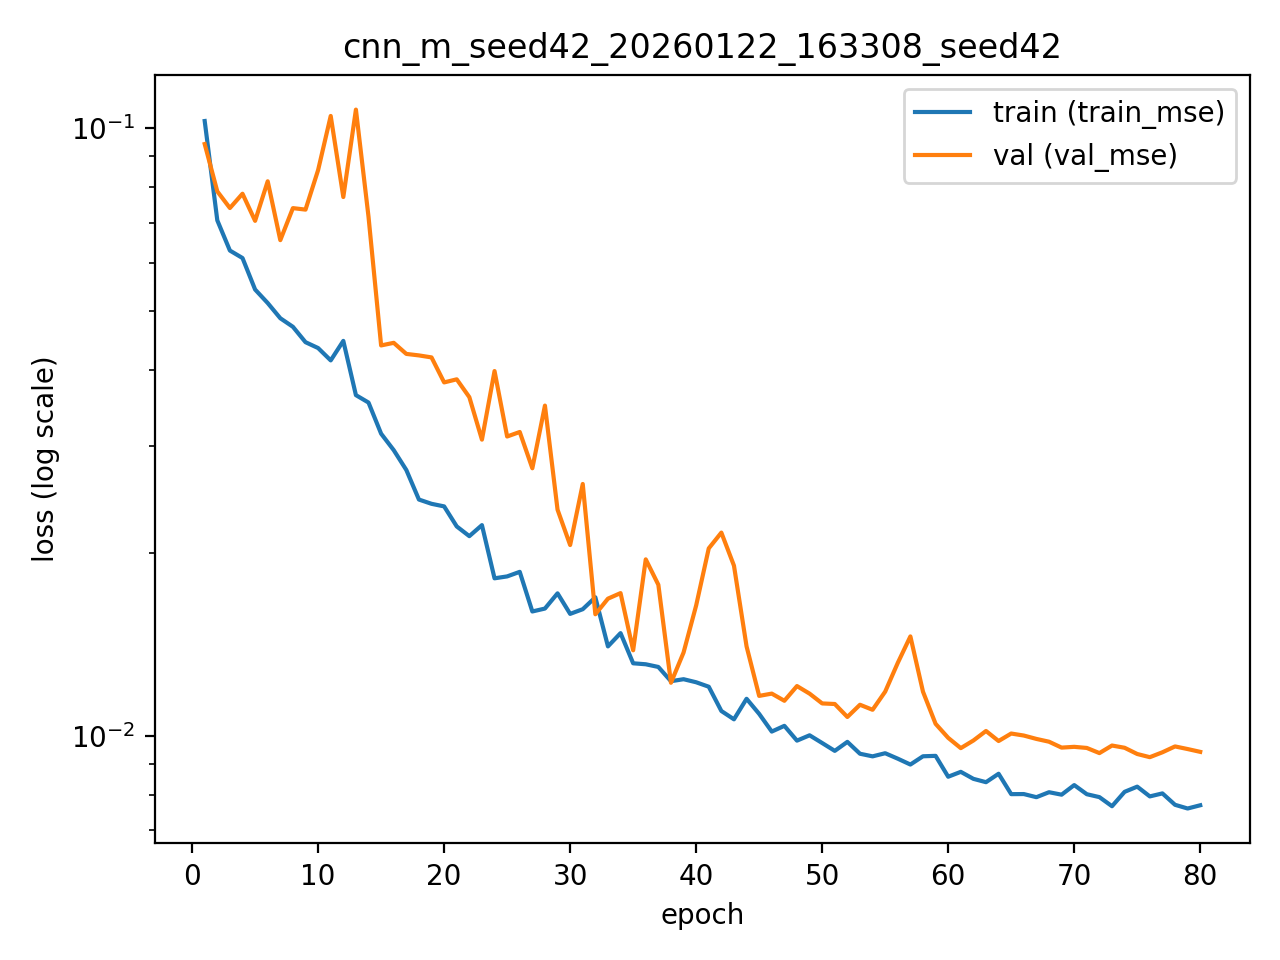

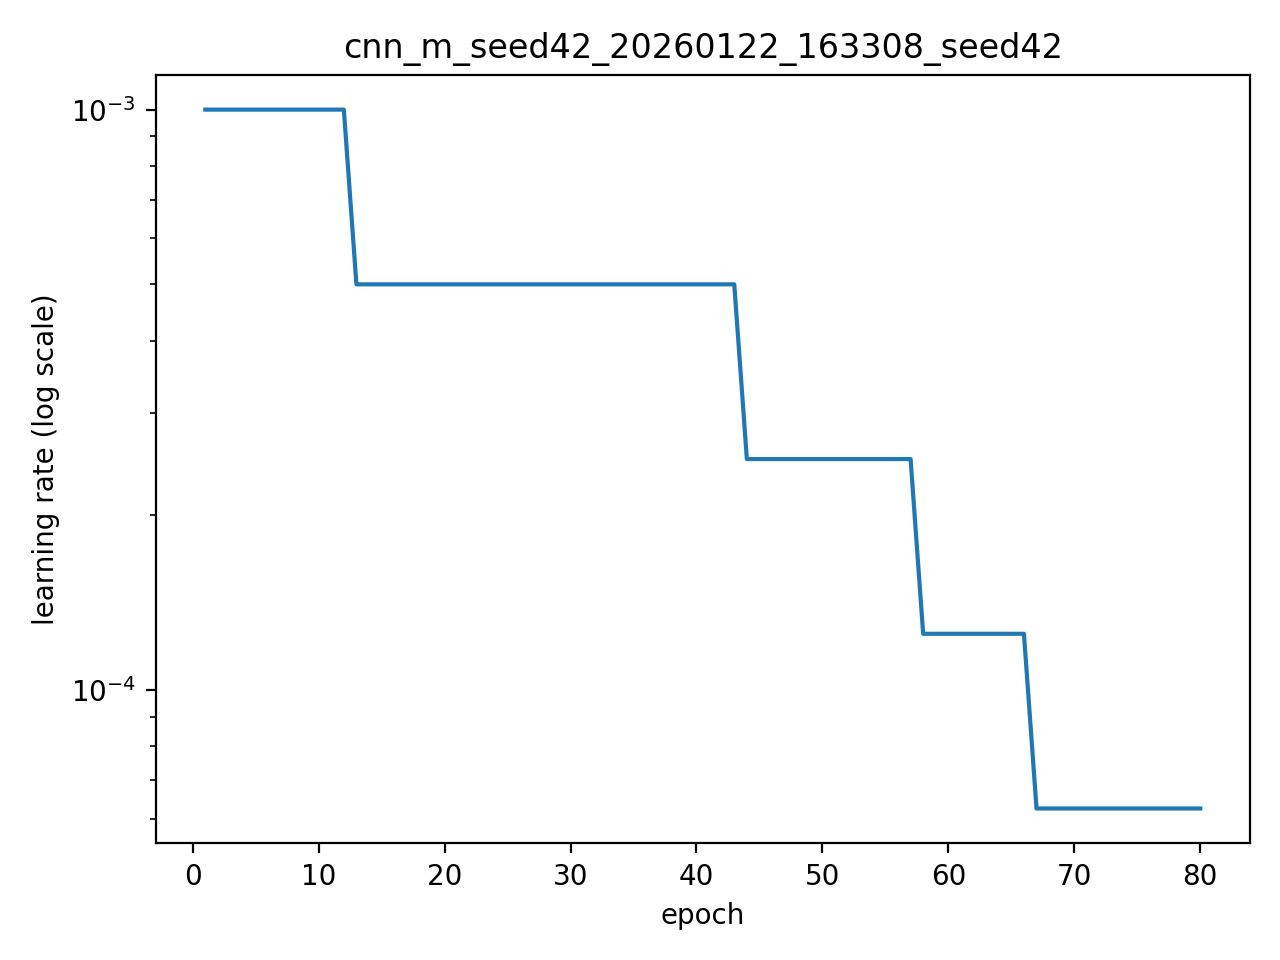


 cnn_l_seed42_20260122_233252_seed42


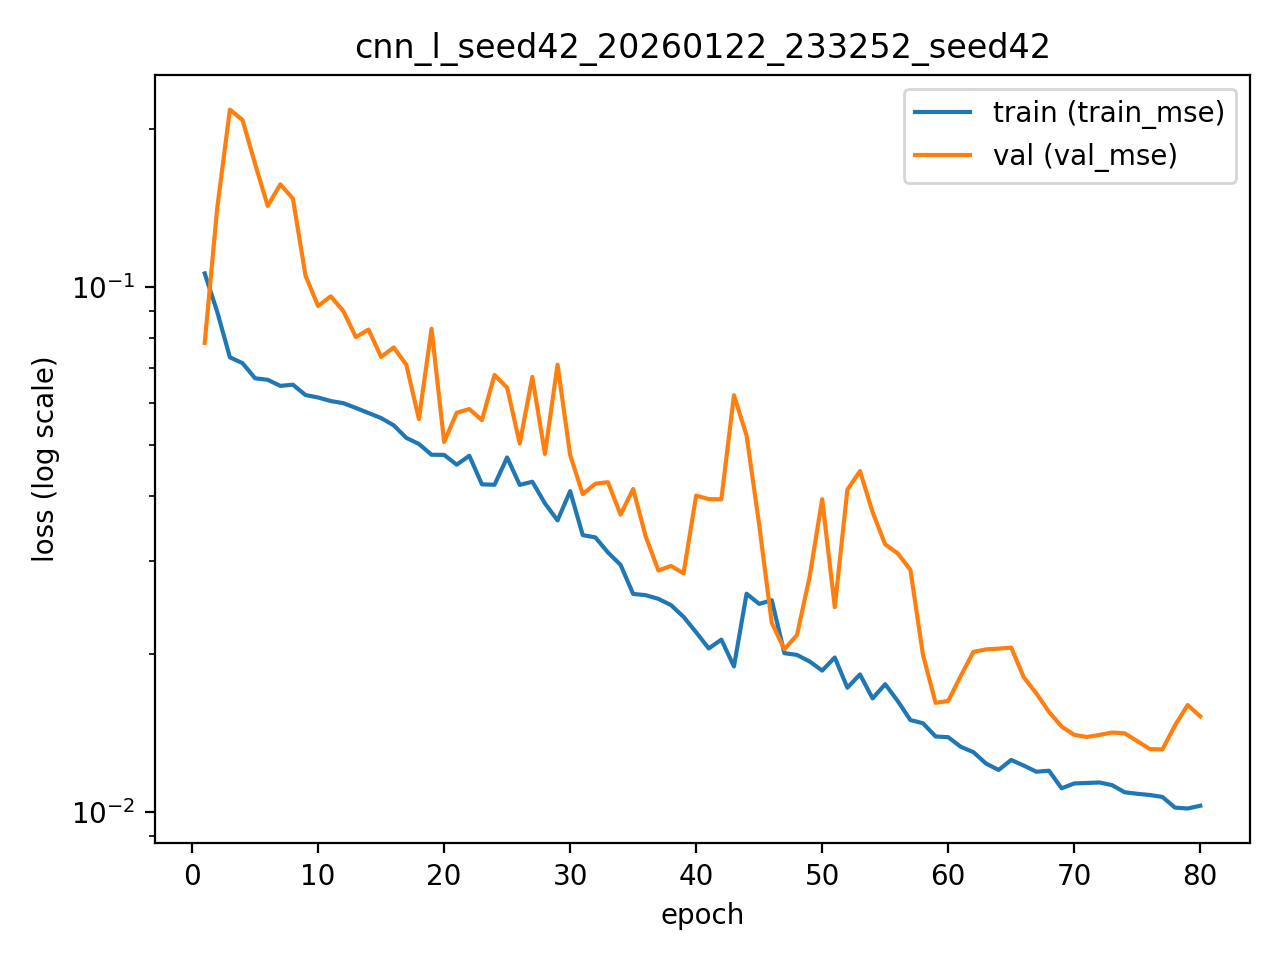

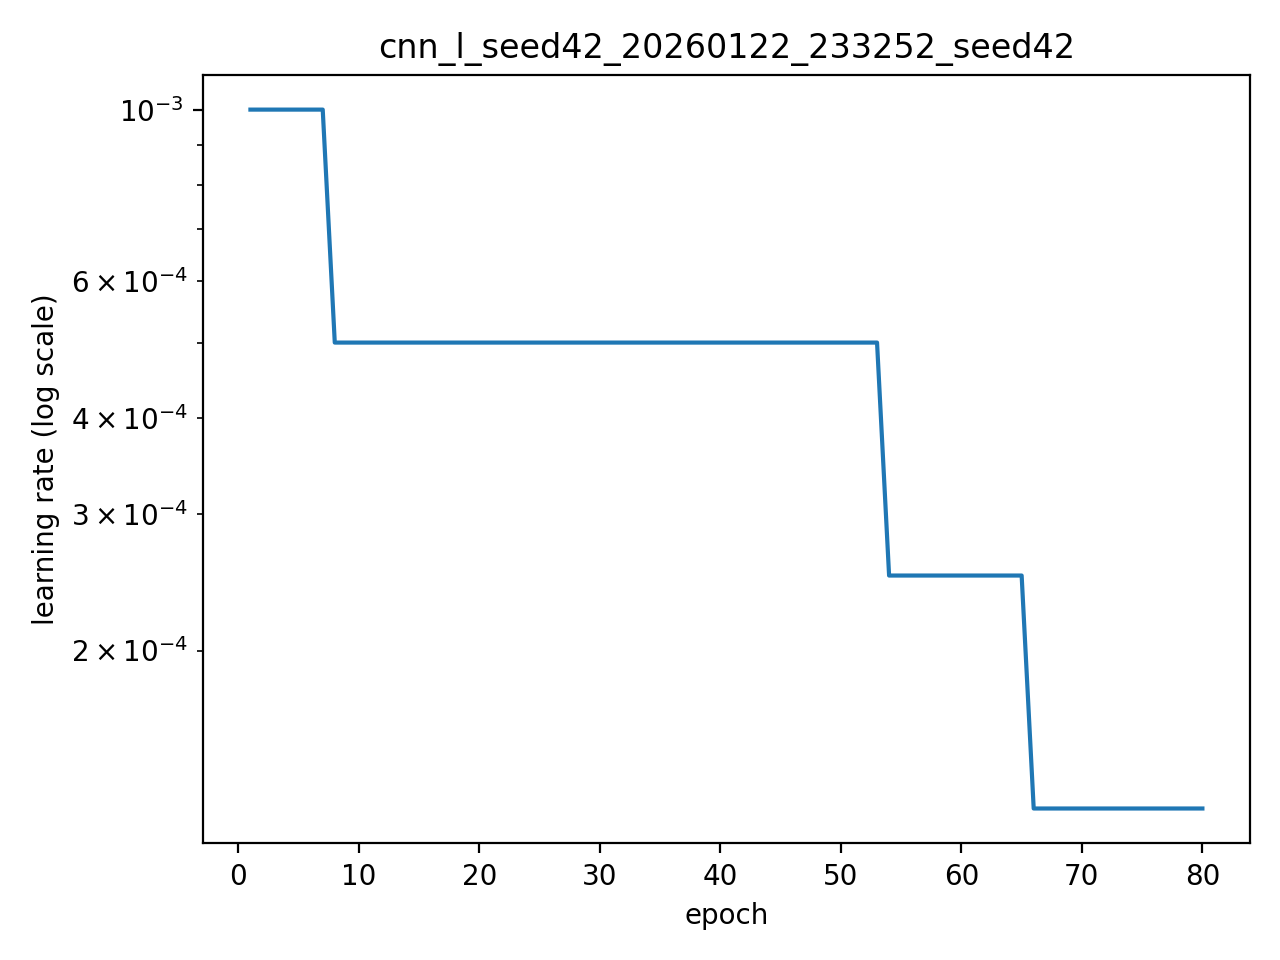


 cnn_xl_seed42_20260123_112702_seed42


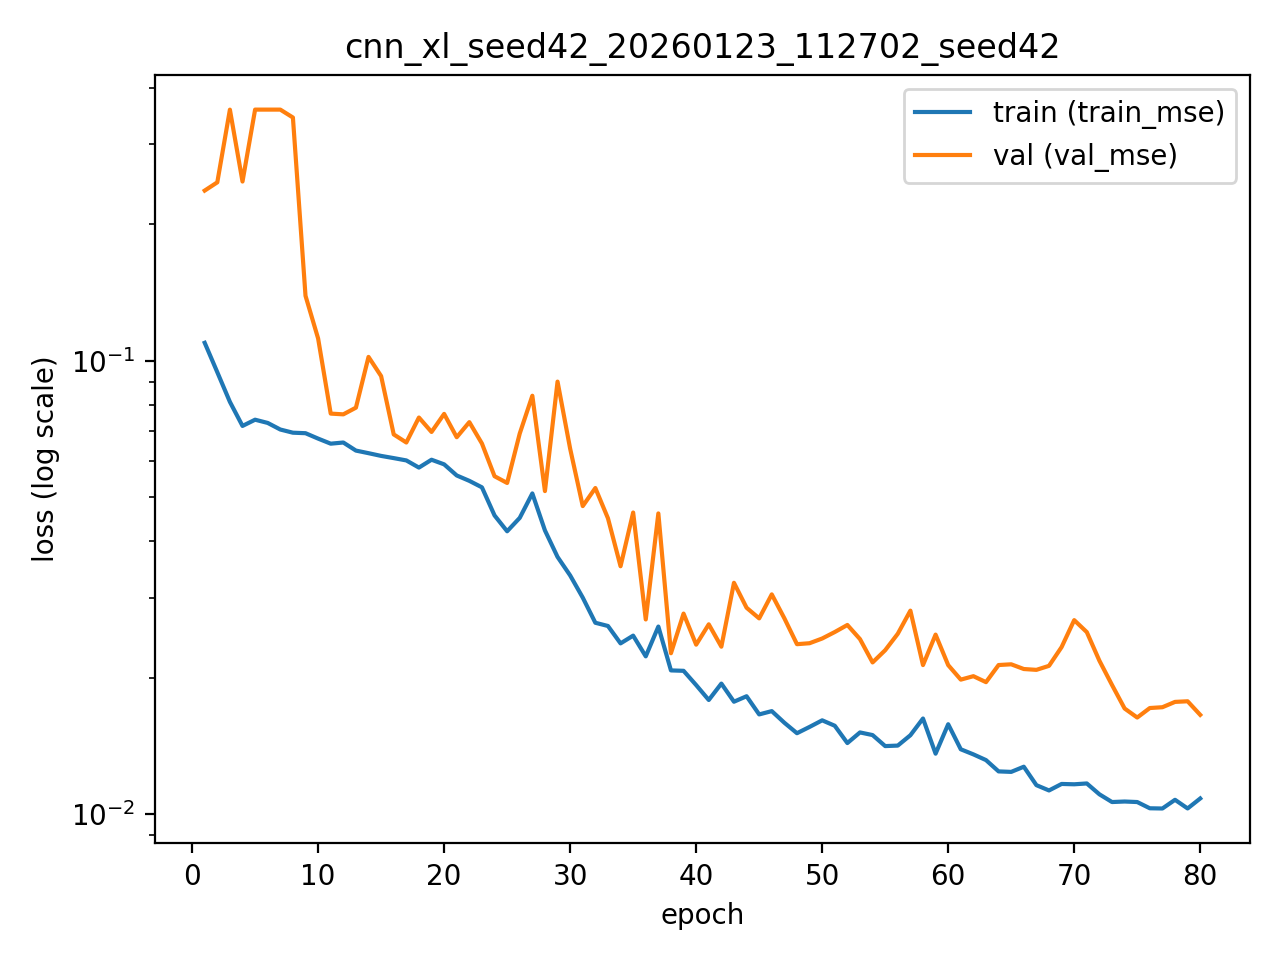

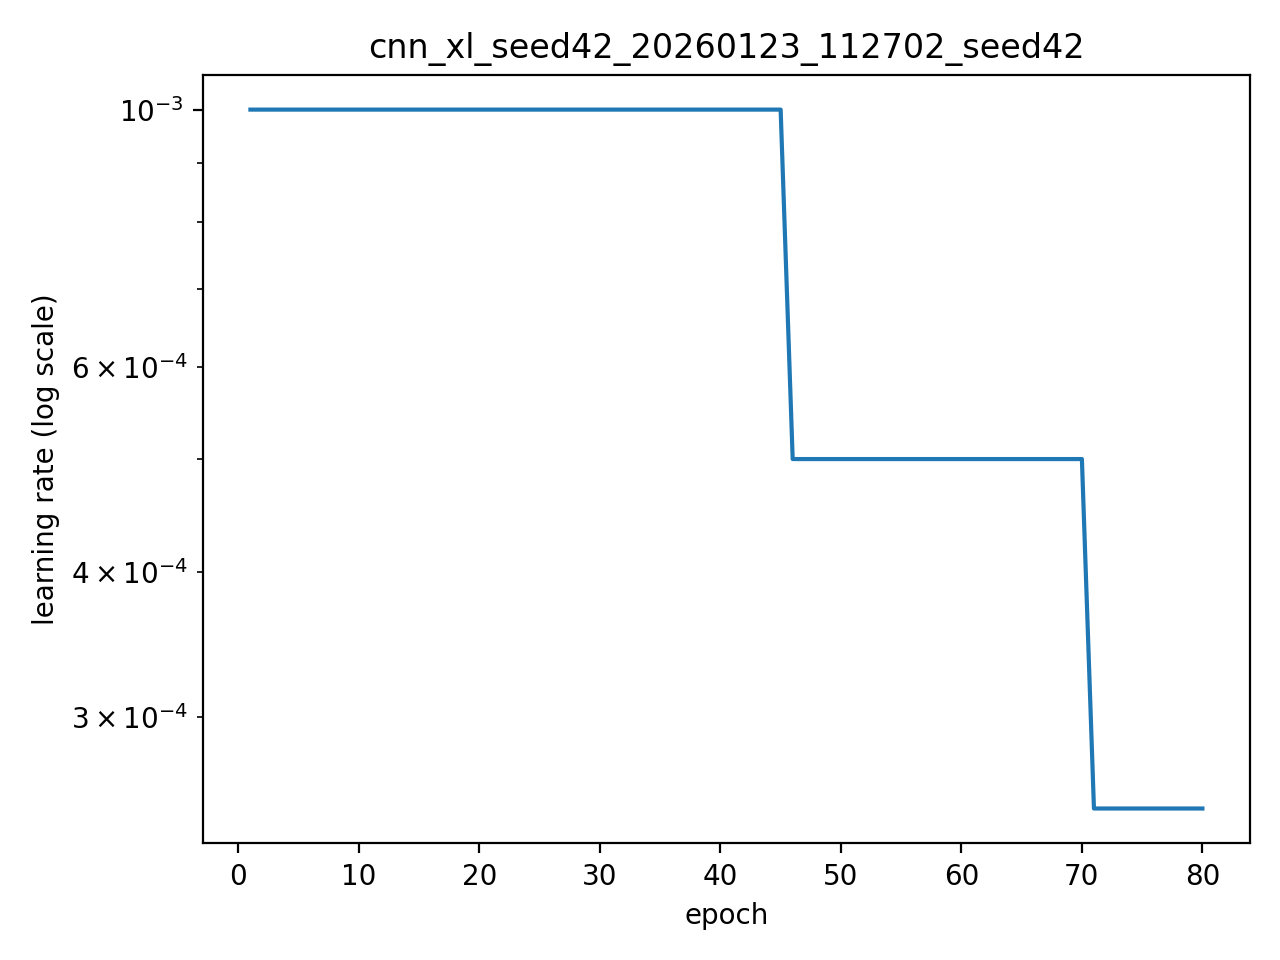


=== FNO ===

 fno_m_seed42


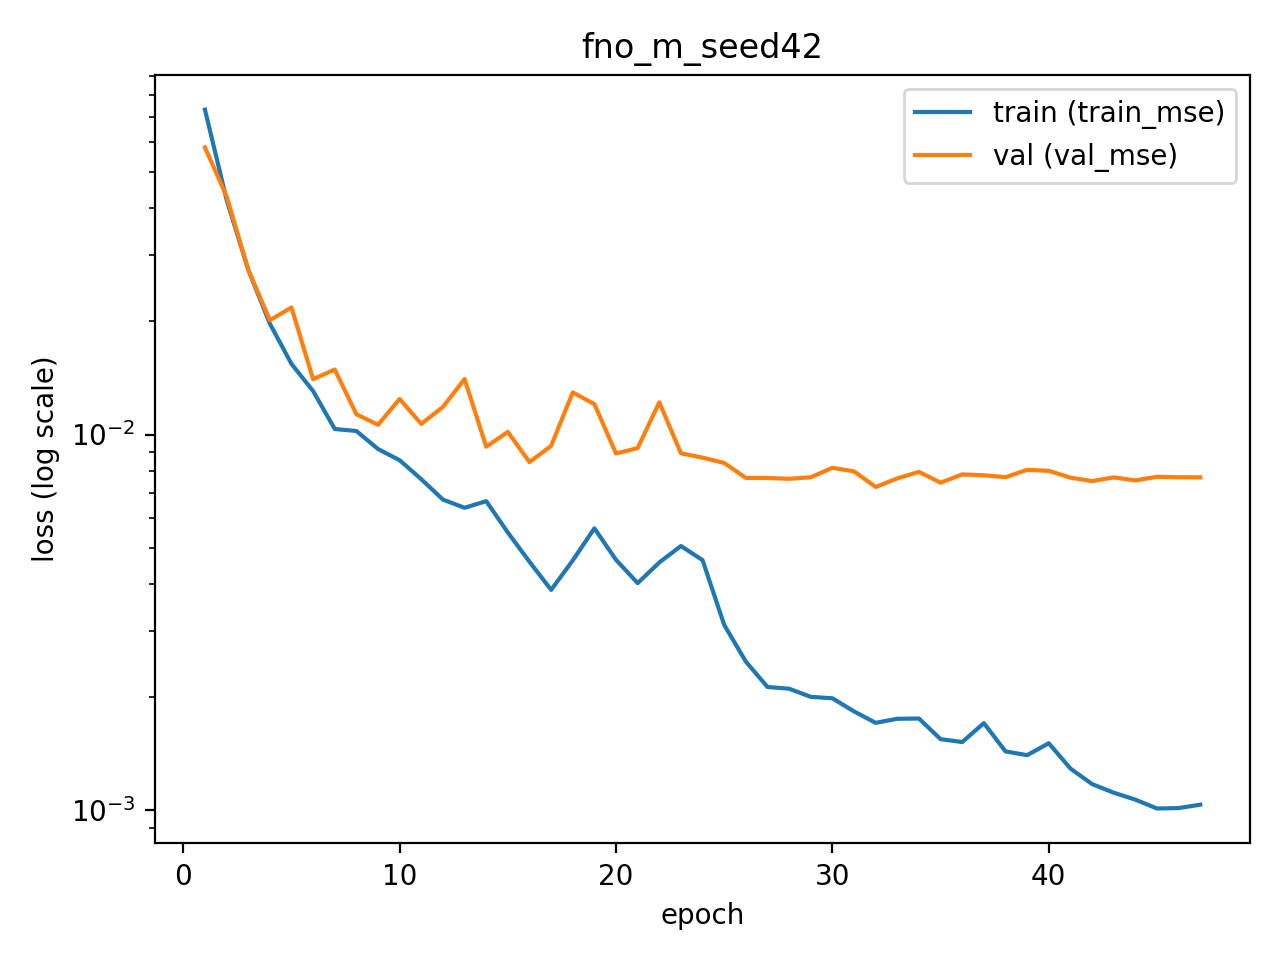

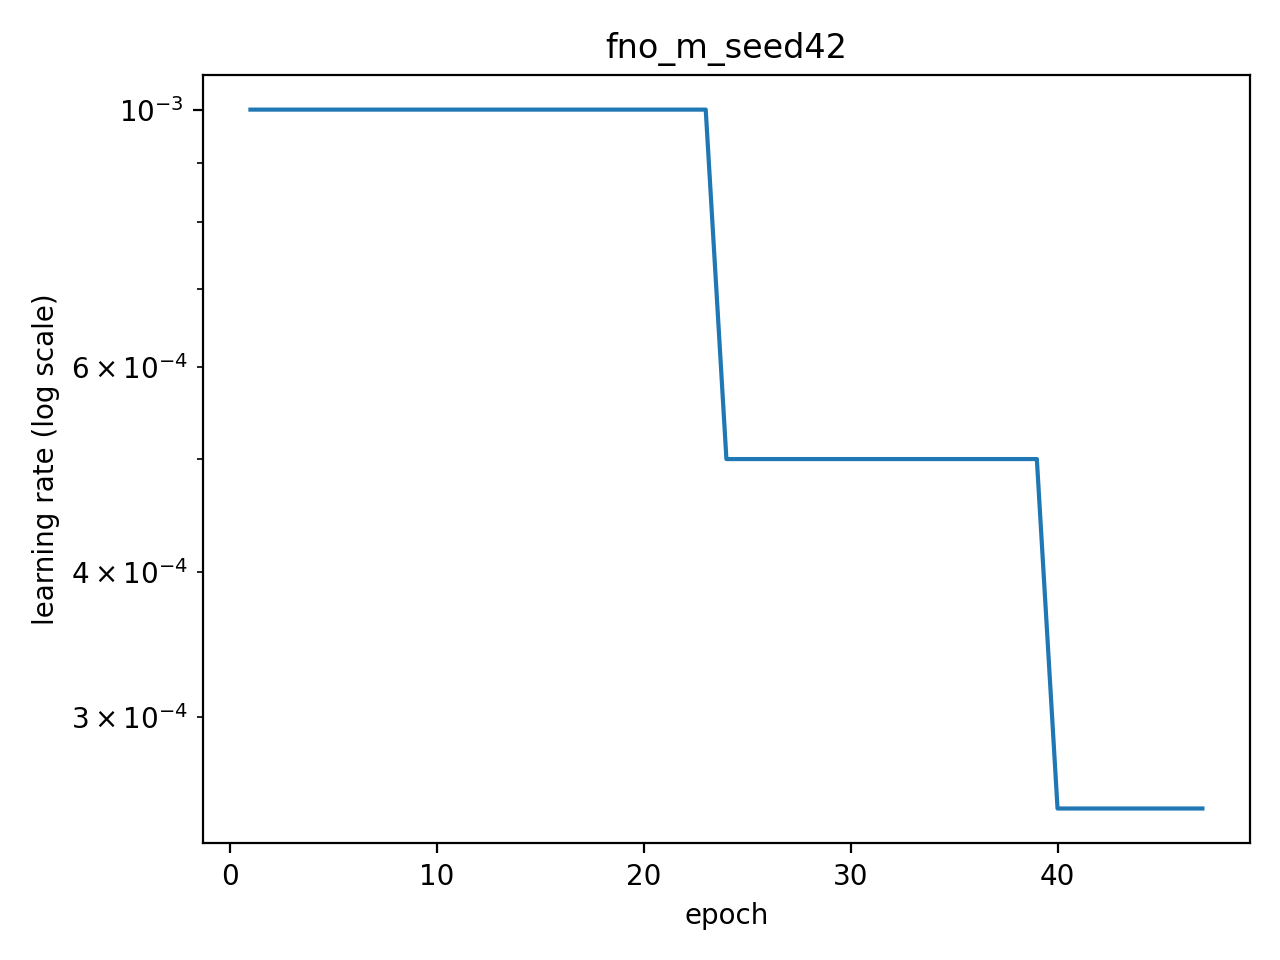


 fno_l_seed42


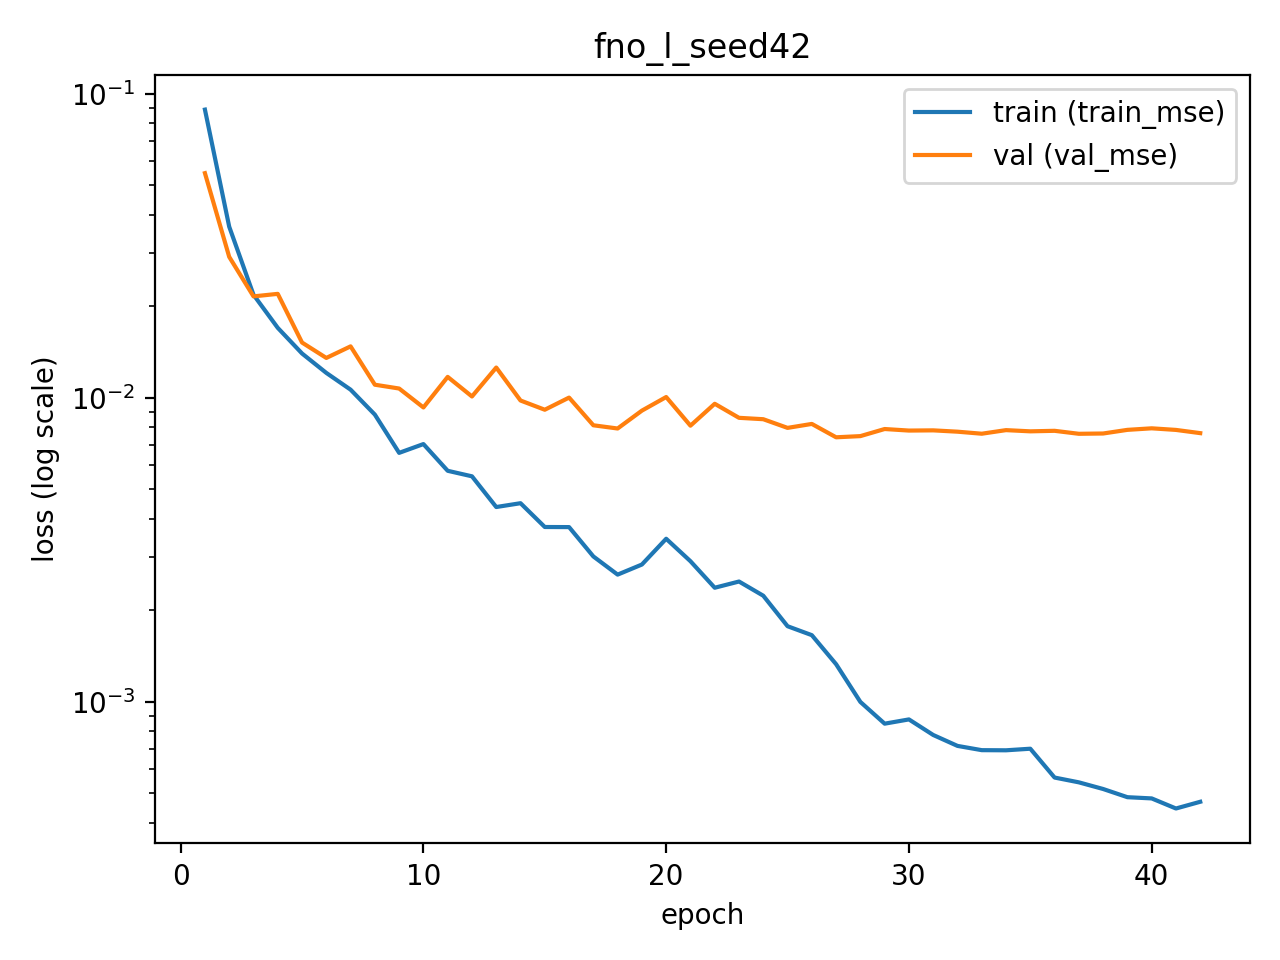

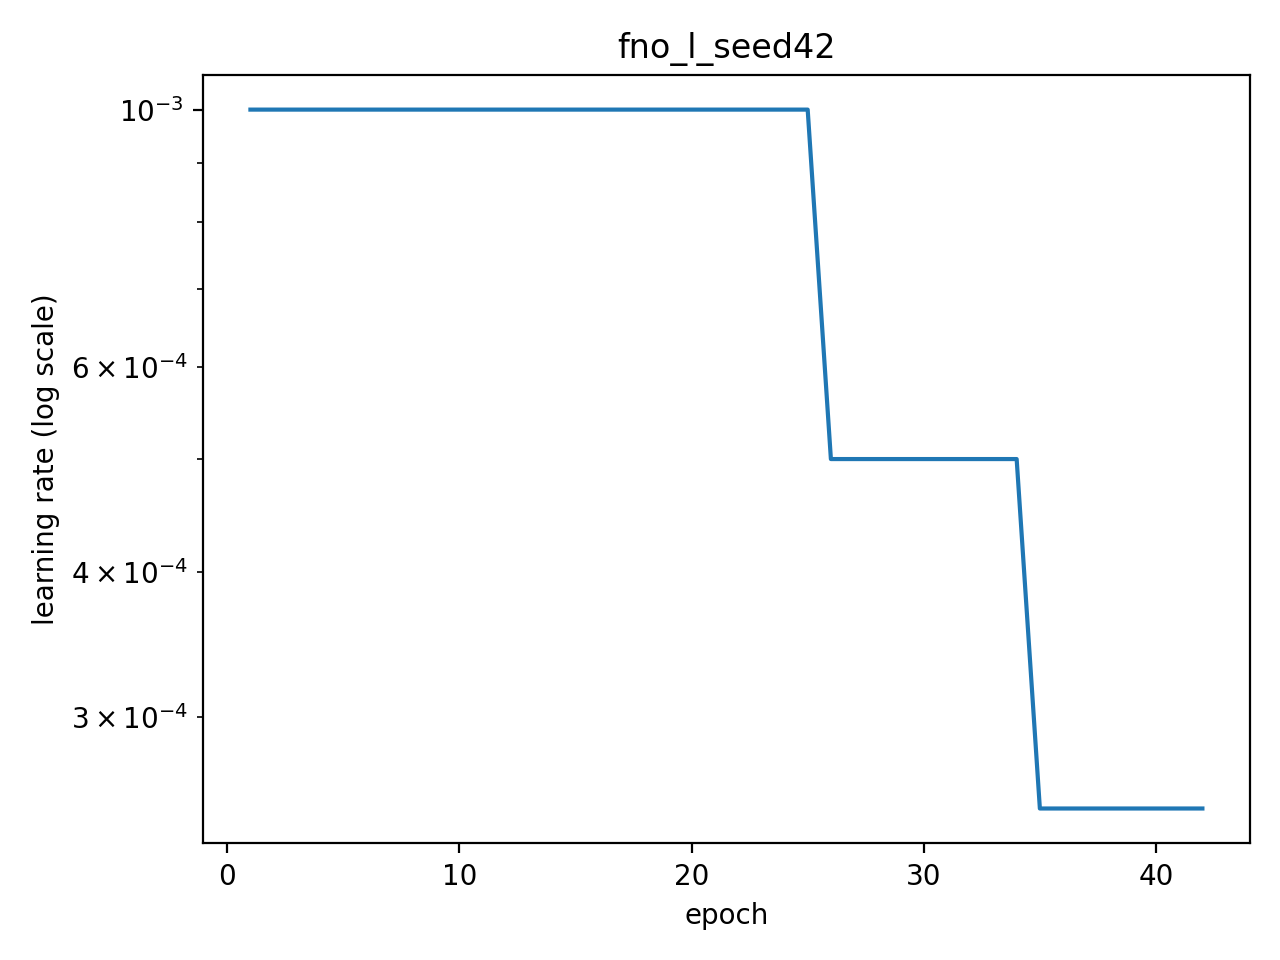


 fno_xl_seed42


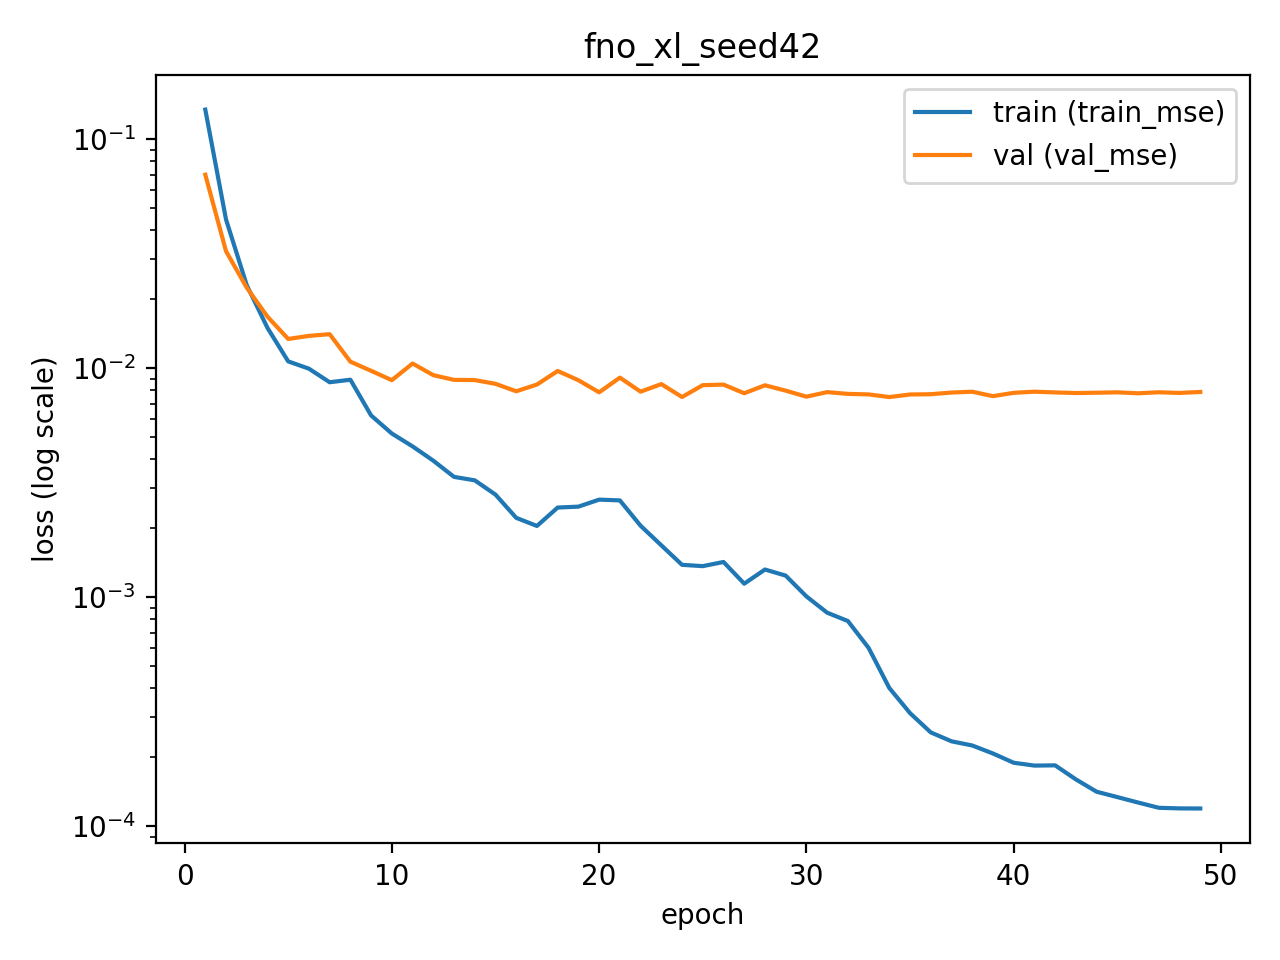

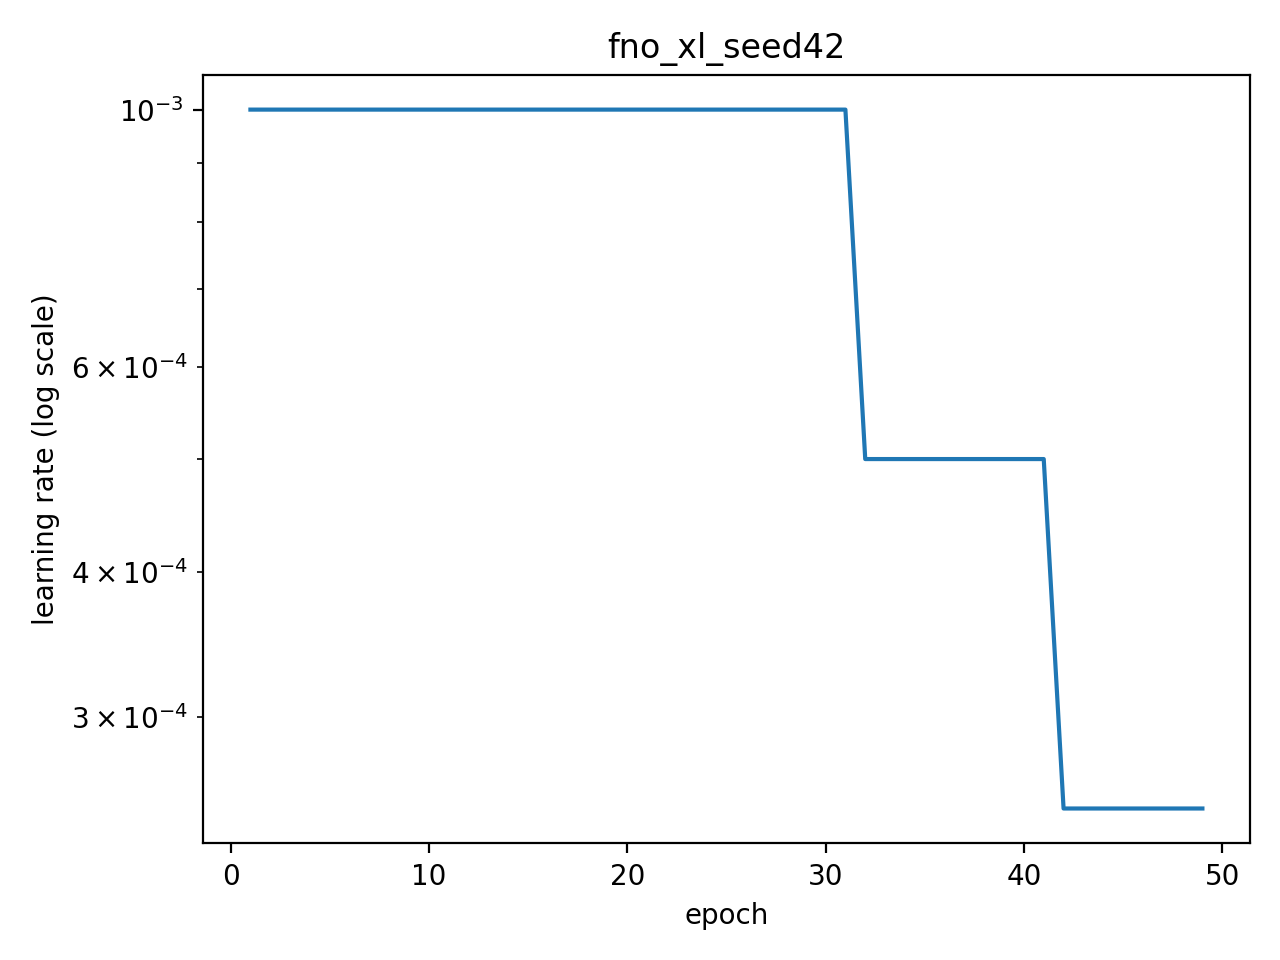

In [8]:
def process_and_show(run_dirs: dict, label: str):
    print(f"\n=== {label} ===")
    for s, d in run_dirs.items():
        if d is None:
            print("missing run dir for size:", s)
            continue
        make_curves(d)

    for s, d in run_dirs.items():
        if d is None:
            continue
        print("\n", d.name)
        loss_img = d / "loss_curve_log.png"
        lr_img = d / "lr_curve.png"
        if loss_img.exists():
            display(Image(filename=str(loss_img)))
        if lr_img.exists():
            display(Image(filename=str(lr_img)))

process_and_show(cnn_run_dirs, "CNN")
process_and_show(fno_run_dirs, "FNO")


In [9]:
import pandas as pd
import json

def summarize_one_run(model_type: str, size: str, run_dir):
    summary_path = run_dir / "summary.json"
    if not summary_path.exists():
        return None

    with open(summary_path, "r") as f:
        summary = json.load(f)

    best_val_mse = summary.get("best_val_mse")
    test_mse = summary.get("test_mse")
    test_r2 = summary.get("test_r2")
    epochs_ran = summary.get("epochs_ran")

    # epochs planned
    epochs_planned = summary.get("epochs_planned")
    if epochs_planned is None:
        epochs_planned = summary.get("training", {}).get("epochs")

    # compute missing fields from history.csv
    hist_path = run_dir / "history.csv"
    best_epoch = None
    train_mse_at_best = None
    val_mse_at_best = None
    val_r2 = None
    generalization_gap = None

    if hist_path.exists():
        h = pd.read_csv(hist_path)
        if "val_mse" in h.columns:
            best_i = h["val_mse"].idxmin()
            best_epoch = int(h.loc[best_i, "epoch"]) if "epoch" in h.columns else int(best_i + 1)
            val_mse_at_best = float(h.loc[best_i, "val_mse"])

            if "train_mse" in h.columns:
                train_mse_at_best = float(h.loc[best_i, "train_mse"])
                generalization_gap = float(val_mse_at_best - train_mse_at_best)

            if "val_r2" in h.columns:
                val_r2 = float(h.loc[best_i, "val_r2"])

            if best_val_mse is None:
                best_val_mse = val_mse_at_best

    return {
        "model": model_type,
        "size": size.upper(),
        "run_dir": run_dir.name,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
        "train_mse_at_best": train_mse_at_best,
        "val_mse_at_best": val_mse_at_best,
        "test_mse": test_mse,
        "val_r2": val_r2,
        "test_r2": test_r2,
        "generalization_gap": generalization_gap,
        "epochs_ran": epochs_ran,
        "epochs_planned": epochs_planned,
        "seed": summary.get("seed", 42),
    }

cnn_rows = []
for s, d in cnn_run_dirs.items():
    if d is None: 
        continue
    row = summarize_one_run("CNN", s, d)
    if row:
        cnn_rows.append(row)
cnn_df = pd.DataFrame(cnn_rows).sort_values("size")

fno_rows = []
for s, d in fno_run_dirs.items():
    if d is None:
        continue
    row = summarize_one_run("FNO", s, d)
    if row:
        fno_rows.append(row)
fno_df = pd.DataFrame(fno_rows).sort_values("size")

In [10]:
cnn_fno_df = pd.concat([cnn_df, fno_df], ignore_index=True).sort_values(["model","size"])
cnn_fno_df

,model,size,run_dir,best_epoch,best_val_mse,train_mse_at_best,val_mse_at_best,test_mse,val_r2,test_r2,generalization_gap,epochs_ran,epochs_planned,seed
0,CNN,L,cnn_l_seed42_20260122_233252_seed42,77,0.013144,0.010673,0.013144,0.013702,0.856911,0.841616,0.002470,80,None,42
1,CNN,M,cnn_m_seed42_20260122_163308_seed42,76,0.009240,0.007964,0.009240,0.011837,0.897714,0.862101,0.001275,80,None,42
2,CNN,XL,cnn_xl_seed42_20260123_112702_seed42,75,0.016351,0.010647,0.016351,0.017328,0.817037,0.793054,0.005703,80,None,42
3,FNO,L,fno_l_seed42,27,0.007409,0.001329,0.007409,0.008695,0.917638,0.907714,0.006080,42,80,42
4,FNO,M,fno_m_seed42,32,0.007251,0.001710,0.007251,0.009991,0.918832,0.893859,0.005541,47,80,42
5,FNO,XL,fno_xl_seed42,34,0.007479,0.000401,0.007479,0.008382,0.917542,0.911846,0.007078,49,80,42


In [ ]:
# cnn_fno_df.to_csv(f"cnn_fno_scaling_summary_seed{SEED}.csv", index=False)